# Prática — Módulo 10 - TF-IDF + KMeans

# **Setup**

In [99]:
# Carregar dados
import pandas as pd

df = pd.read_excel("/content/3_2_feature_engineering_nicho_safe_1024.xlsx")

print("Shape:", df.shape)


Shape: (1024, 6)


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ClienteCod             1024 non-null   int64 
 1   ConteudoCod            1024 non-null   int64 
 2   ConteudoNome           1024 non-null   object
 3   ConteudoCategoriaNome  1021 non-null   object
 4   ConteudoDescricao      1023 non-null   object
 5   ConteudoObservacao     29 non-null     object
dtypes: int64(2), object(4)
memory usage: 48.1+ KB


# **Fase 0 - Engenharia de Atributos**

### EDA

In [101]:
# Realizar diagnóstico básico (nulos e duplicatas)

print("Linhas:", len(df))
print("Clientes únicos:", df["ClienteCod"].nunique())
print("Conteúdos únicos:", df["ConteudoCod"].nunique())

print("\nNulos por coluna:")
print(df.isnull().sum())

print("\nDuplicados (linhas inteiras):")
print(df.duplicated().sum())

Linhas: 1024
Clientes únicos: 658
Conteúdos únicos: 1024

Nulos por coluna:
ClienteCod                 0
ConteudoCod                0
ConteudoNome               0
ConteudoCategoriaNome      3
ConteudoDescricao          1
ConteudoObservacao       995
dtype: int64

Duplicados (linhas inteiras):
0


In [102]:
# Verificar quantas categorias existem
cats = (
    df["ConteudoCategoriaNome"]
    .str.lower()
    .str.split(";")
    .explode()
    .str.strip()
)

print("Total categorias únicas:", cats.nunique())

print(
    cats.value_counts(ascending=False)
)

Total categorias únicas: 105
ConteudoCategoriaNome
vendas                         263
educação                       149
saúde                          110
desenvolvimento pessoal         86
marketing digital               63
autoajuda e desenv. pessoal     62
empreendedorismo                56
saúde, dieta e beleza           55
finanças                        41
educação financeira             38
educação física e esporte       37
psicologia                      34
espiritualidade                 34
relacionamento e familia        31
negócios e dinheiro             29
educação e carreiras            29
administração e negócios        28
beleza e estética               27
administração e gestão          27
marketing                       26
tecnologia                      19
evangélico                      19
religião e espiritualidade      18
investimentos                   18
produtividade                   17
arte e entretenimento           17
outros                          17
curs

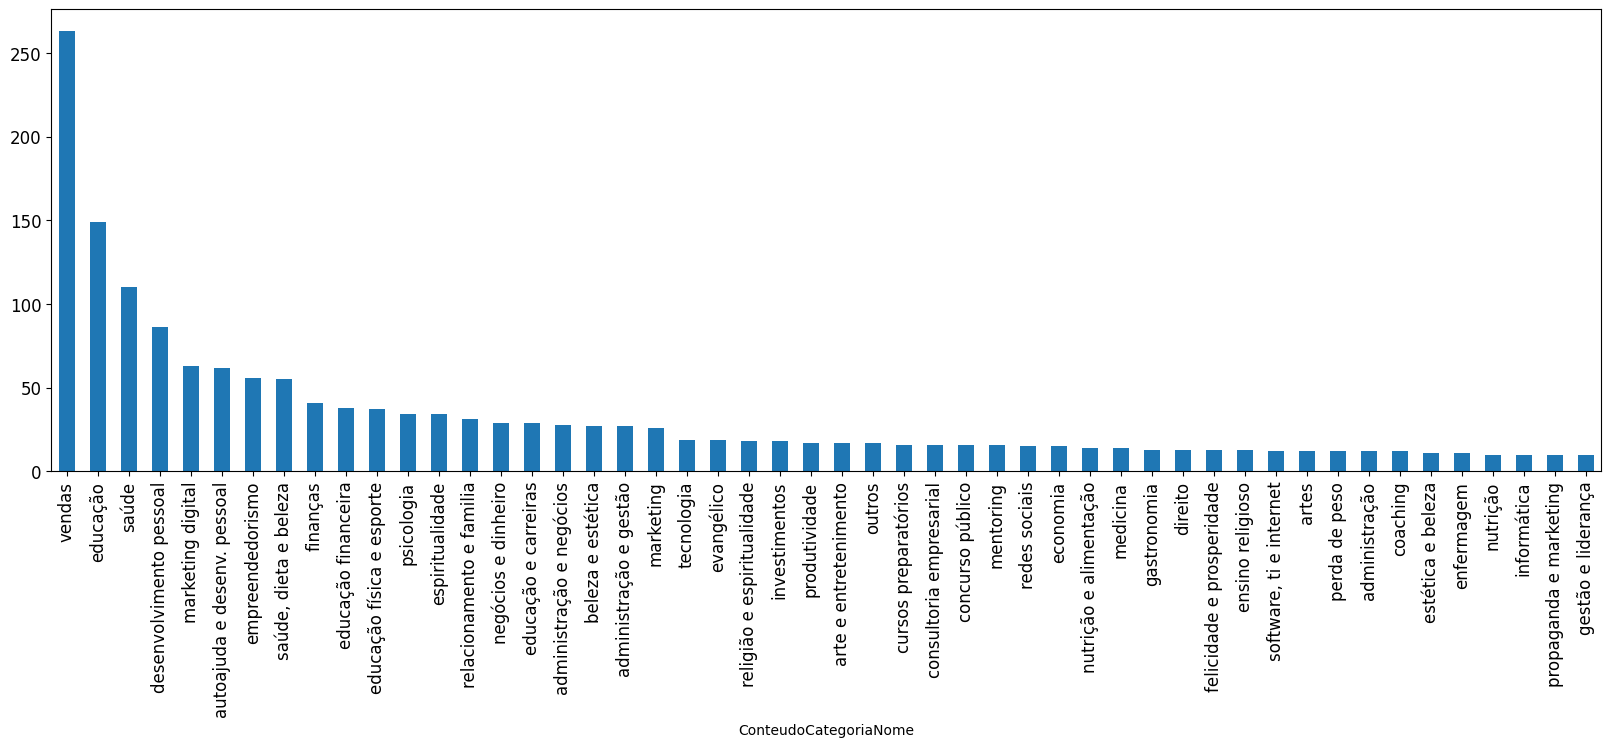

In [103]:
# Entender a variável categorias que seria o sinal mais relevante
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))           # proporção largura vs altura

cats.value_counts().head(50).plot(kind="bar")

plt.xticks(rotation=90, fontsize=12)  # aumenta tamanho da fonte no eixo X
plt.yticks(fontsize=12)               # aumenta no eixo Y

#plt.tight_layout()
plt.show()


## Limpeza

In [104]:
# Remover ocorrências de conteúdos cadastrados somente na categoria "Outros" isoladamente
df = df[
    ~(
        df["ConteudoCategoriaNome"]
        .str.lower()
        .str.strip()
        .isin(["outros"])
    )
]

In [105]:
df.count()

,0
ClienteCod,1013
ConteudoCod,1013
ConteudoNome,1013
ConteudoCategoriaNome,1010
ConteudoDescricao,1012
ConteudoObservacao,29


In [106]:
# Remover registros com ConteudoDescricao e ConteudoNome nulos
before = df.count()

df = df.dropna(subset=["ConteudoDescricao"])
df = df.dropna(subset=["ConteudoNome"])

after = df.count()

print("Removidos:", before - after)

Removidos: ClienteCod               1
ConteudoCod              1
ConteudoNome             1
ConteudoCategoriaNome    0
ConteudoDescricao        0
ConteudoObservacao       0
dtype: int64


In [107]:
# Selecionar variáveis relevantes
df = df[
    [
        "ClienteCod",
        "ConteudoCod",
        "ConteudoNome",
        "ConteudoDescricao",
        "ConteudoCategoriaNome",
    ]
]

df.head()

,ClienteCod,ConteudoCod,ConteudoNome,ConteudoDescricao,ConteudoCategoriaNome
0,68491469,2630949,Curso completo Polícia Militar de Sergipe,Curso preparatório completo em PDF e vídeo aulas para o concurso da Polícia Militar do estado de Sergipe.,Concurso Público
1,59703456,2791336,Mentoria - OXP,"Mentoria OXP\nAcompanhamento Estratégico para Clínicas Odontológicas\n\n&lt; Precificação, gestão financeira, repasses a dentistas e impostos &gt;\nA Mentoria OXP é um programa de 4 meses com encontros quinzenais ao vivo, criado para dentistas e gestores que desejam corrigir erros de precificação, gerir o financeiro corretamente, e estruturar uma operação com previsibilidade, segurança e lucro. Com um passo a passo prático, você será guiado(a) por especialistas que vivem odontologia na prática há +20 anos, com foco em resultado!\n\nComo funciona\n\nDuração: 4 meses - 8 lives quinzenais ao vivo\nFormato: Aulas online + ferramentas + grupo de suporte para dúvidas + 1 hora de sessão individual com os mentores\nMaterial: Planilhas inteligentes, PDFs, gravações e suporte total nos 4 meses\nAcesso por 1 ano ao Curso OdontoMap\n7 dias de garantia de satisfação\n\n&gt; Módulo 1: Precificação Estratégica (4 lives)\nImersão completa na Metodologia de Precificação OdontoMAP, com planilha personalizada, cálculo do custo real, margem por procedimento e definição de preços sustentáveis.\n\n1. Live de Abertura + Raio-X da Clínica\n\nAqui começa sua virada de chave. Logo na primeira sessão você terá acesso a um conteúdo prático sobre método de precificação da OdontoMap. Vamos te mostrar onde clínicas erram ao precificar – e como evitar esses erros.\nVocê também receberá nossa ferramenta exclusiva de Raio-X para diagnosticar o que drena o seu lucro na sua precificação e mais uma ferramenta para levantar os principais dados da sua clínica.\nEssa etapa é essencial para montar a base do seu OdontoMap – e vamos te guiar passo a passo nessa coleta!\n\n2. Live do Passo a Passo da Precificação – Sessão Guiada\n\nPlanilha aberta, mão na massa! Com os números já organizados, você aprenderá como preencher a Planilha de Precificação OdontoMap, linha por linha.\nTudo isso será feito junto com você, ao vivo, para garantir que você saia da sessão com sua planilha pronta para uso.\n\n3. Live de Revisão dos Números e Re-precificação Lucrativa\n\nAgora é hora da virada: você verá, com seus próprios dados, quais procedimentos te dão lucro – e quais geram prejuízo.\nNesta live, vamos te ensinar a analisar a sua planilha, avaliar o resultado, a margem, e lucro ou prejuízo por procedimento. Depois, aplicaremos a re-precificação estratégica: reajustando os valores com base em margens sustentáveis!\n\n4. Live de Dúvidas com os Mentores\n\nSabemos que dúvidas surgem no processo – e aqui é o espaço para resolvê-las. Essa sessão ao vivo será totalmente dedicada às perguntas dos mentorados, com respostas personalizadas, orientações práticas e casos reais.\n\n&gt; Módulo 2: Gestão Financeira na Prática (2 lives)\n\nVocê aprenderá como estruturar o financeiro da clínica e tomar decisões baseadas em dados – mesmo sem ter formação em finanças.\n\n5. Live de Fundamentos da Gestão Financeira\nOrganização do fluxo de caixa, separação das contas pessoais, metas, controle de despesas e estrutura mínima para uma gestão eficiente.\n\n6. Live de Indicadores e Tomada de Decisão\nComo acompanhar os resultados da clínica, o faturamento e a margem, e como tomar as melhores decisões baseadas em dados.\n\n&gt; Módulo 3: Repasses para Dentistas (1 live)\n\nDescubra qual o melhor modelo de repasse para sua clínica. Vamos apresentar as 4 formas mais utilizadas no mercado, com vantagens, desvantagens e os cuidados que você deve ter para cada uma delas.\nVocê sairá com clareza sobre o modelo ideal para sua realidade e como aplicá-lo de forma justa e estratégica\n\n&gt; Módulo 4: Impostos na Odontologia (1 live)\n\nAprenda, de forma simples e objetiva, qual o melhor regime tributário para sua clínica. V

In [108]:
df[df["ClienteCod"] == 98815559]

,ClienteCod,ConteudoCod,ConteudoNome,ConteudoDescricao,ConteudoCategoriaNome
79,98815559,2654907,Boi Que Deixa Dinheiro - 3ª Edição - Natalia Martins,"O Boi Que Deixa Dinheiro é um evento agropecuário realizado em Cuiabá, reunindo pecuaristas e profissionais do setor para discutir tendências, tecnologias e estratégias que aumentem a rentabilidade na pecuária. Com palestras e painéis dinâmicos, aborda temas como sucessão familiar, gestão de pessoas e inovações no agro. A edição de 2025, com o tema “Herdeiros do Campo: Inovando sem Perder as Raízes“, foca na união entre tradição e inovação. O evento também é uma plataforma para empresas apresentarem soluções e promove networking qualificado, transformando desafios do setor em oportunidades de crescimento sustentável.",Vendas
80,98815559,2640314,Boi Que Deixa Dinheiro - 3ª Edição - Convidado Rafael - Convidado Rafael,"O Boi Que Deixa Dinheiro é um evento agropecuário realizado em Cuiabá, reunindo pecuaristas e profissionais do setor para discutir tendências, tecnologias e estratégias que aumentem a rentabilidade na pecuária. Com palestras e painéis dinâmicos, aborda temas como sucessão familiar, gestão de pessoas e inovações no agro. A edição de 2025, com o tema “Herdeiros do Campo: Inovando sem Perder as Raízes“, foca na união entre tradição e inovação. O evento também é uma plataforma para empresas apresentarem soluções e promove networking qualificado, transformando desafios do setor em oportunidades de crescimento sustentável.",Vendas
81,98815559,2654916,Boi Que Deixa Dinheiro - 3ª Edição - Ivanor piran - Ivanor piran,"O Boi Que Deixa Dinheiro é um evento agropecuário realizado em Cuiabá, reunindo pecuaristas e profissionais do setor para discutir tendências, tecnologias e estratégias que aumentem a rentabilidade na pecuária. Com palestras e painéis dinâmicos, aborda temas como sucessão familiar, gestão de pessoas e inovações no agro. A edição de 2025, com o tema “Herdeiros do Campo: Inovando sem Perder as Raízes“, foca na união entre tradição e inovação. O evento também é uma plataforma para empresas apresentarem soluções e promove networking qualificado, transformando desafios do setor em oportunidades de crescimento sustentável.",Vendas
82,98815559,2651318,Boi Que Deixa Dinheiro - 3ª Edição - Fazenda Nacional - Fazenda Nacional,"O Boi Que Deixa Dinheiro é um evento agropecuário realizado em Cuiabá, reunindo pecuaristas e profissionais do setor para discutir tendências, tecnologias e estratégias que aumentem a rentabilidade na pecuária. Com palestras e painéis dinâmicos, aborda temas como sucessão familiar, gestão de pessoas e inovações no agro. A edição de 2025, com o tema “Herdeiros do Campo: Inovando sem Perder as Raízes“, foca na união entre tradição e inovação. O evento também é uma plataforma para empresas apresentarem soluções e promove networking qualificado, transformando desafios do setor em oportunidades de crescimento sustentável.",Vendas
83,98815559,2642757,Boi Que Deixa Dinheiro - 3ª Edição - Agro. Bom Pastor -Convidados l,"O Boi Que Deixa Dinheiro é um evento agropecuário realizado em Cuiabá, reunindo pecuaristas e profissionais do setor para discutir tendências, tecnologias e estratégias que aumentem a rentabilidade na pecuária. Com palestras e painéis dinâmicos, aborda temas como sucessão familiar, gestão de pessoas e inovações no agro. A edição de 2025, com o tema “Herdeiros do Campo: Inovando sem Perder as Raízes“, foca na união entre tradição e inovação. O evento também é uma plataforma para empresas apresentarem soluções e promove networking qualificado, transformando desafios do setor em oportunidades de crescimento sustentável.",Vendas
84,98815559,2643980,Boi Que Deixa Dinheiro - 3ª Edição - Convidados Sr. Nenê Silveira,"O Boi Que Deixa Dinheiro é um evento agropecuário realizado em Cuiabá, reunindo pecuaristas e profissionais do setor para discutir tendências, tecnologias e estratégias que aumentem a rentabilidade na pecuária. Com palestras e painéis

## Pergunta
1. Que problema surge ao tentar agrupar (clusterizar) conteúdos com pouca variação textual?

## Criação de Atributo (qtd_conteudos)

In [109]:
# Contar quantos conteúdos existem por cliente + categoria
counts = (
    df.groupby(["ClienteCod", "ConteudoCategoriaNome"])
      .size()
      .reset_index(name="qtd")
)

df = df.merge(counts, on=["ClienteCod", "ConteudoCategoriaNome"])

In [110]:
# Agrupar conteúdos repetidos concatenando textos e contando quantos foram agregados
# Separar categorias repetidas (qtd>1)
df_rep = df[df["qtd"] > 1]

df_rep_agg = (
    df_rep
    .groupby(["ClienteCod", "ConteudoCategoriaNome"])
    .agg({
        "ConteudoNome": lambda x: ", ".join(pd.unique(x)),
        "ConteudoDescricao": lambda x: ", ".join(pd.unique(x)),
        "ConteudoCod": "count"
    })
    .rename(columns={"ConteudoCod": "qtd_conteudos"})
    .reset_index()
)

In [111]:
# Preparar conteúdos únicos mantendo texto e atribuindo quantidade de conteúdo igual 1
# Separar categorias únicas (qtd=1)
df_uni = df[df["qtd"] == 1]

df_uni = df_uni[[
    "ClienteCod",
    "ConteudoCategoriaNome",
    "ConteudoNome",
    "ConteudoDescricao"
]].copy()

df_uni["qtd_conteudos"] = 1

In [112]:
# Unir conteúdos únicos e agregados em um único dataset final
df_final = pd.concat([df_uni, df_rep_agg], ignore_index=True)

In [113]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ClienteCod             736 non-null    int64 
 1   ConteudoCategoriaNome  736 non-null    object
 2   ConteudoNome           736 non-null    object
 3   ConteudoDescricao      736 non-null    object
 4   qtd_conteudos          736 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 28.9+ KB


## Stopwords

In [114]:
# Gerar candidatos a stopwords a partir do dataset
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

text = (df_final["ConteudoNome"] + " " + df_final["ConteudoDescricao"]).fillna("")

vec = CountVectorizer(
    lowercase=True,
    token_pattern=r"\b\w+\b",
    max_df=0.6,   # aparece em > 60% docs → muito comum
    min_df=2      # ignora raros
)

X = vec.fit_transform(text)

terms = np.array(vec.get_feature_names_out())
freq = np.asarray(X.sum(axis=0)).ravel()

df_terms = (
    pd.DataFrame({"termo": terms, "freq": freq})
    .sort_values("freq", ascending=False)
)

df_terms.head(50)

,termo,freq
5447,é,1162
1474,da,1161
1079,como,826
5211,uma,783
3583,no,776
4868,sua,761
3239,mais,677
4666,se,648
4760,seu,638
3733,os,572


In [115]:
# Remover stopwords etc. (números + meses + pontuação)
# A remoção é feita apenas em ConteudoNome e ConteudoDescricao
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

# 1. Stopwords gramaticais
stopwords_gramaticais = set(stopwords.words("portuguese"))

# 2. Stopwords automáticas (top frequência)
stopwords_auto = set(df_terms["termo"].head(50).tolist())

# 3. Stopwords de marketing/plataforma
stopwords_marketing = {
    "curso","cursos","vendas","mentoria","ebook","programa","treinamento",
    "vip","oficial","completo","acesso","garantia",
    "shopee", "mercado livre",
    "checkout","plataforma"
}

# 4. Stopwords estruturais (CRÍTICAS)
stopwords_estruturais = {
    "desenvolvimento","desenv","pessoal",
    "educação","educacional",
    "gestão","gerenciamento",
    "qualidade","melhoria",
    "sucesso","resultado",
    "conhecimento","aprendizado",
    "habilidade","competência",
    "ferramentas","técnicas","estratégias",
    "introdução","iniciação",
    "profissional","profissionalizante", "3d"
}

# 5. Stopwords temporais
meses = {
    "janeiro","fevereiro","março","abril","maio","junho",
    "julho","agosto","setembro","outubro","novembro","dezembro"
}

# 6. Consolidação
stopwords_total = (
    stopwords_gramaticais
    | stopwords_auto
    | stopwords_marketing
    | stopwords_estruturais
)

# 7. Função de limpeza
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\d+", " ", s)

    tokens = s.split()

    tokens = [t for t in tokens if t not in stopwords_total]
    tokens = [t for t in tokens if t not in meses]

    return " ".join(tokens)

# 8. Aplicação
df_final["nome_limpo"] = df_final["ConteudoNome"].apply(clean_text).str[:300]
df_final["desc_limpa"] = df_final["ConteudoDescricao"].apply(clean_text).str[:300]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [116]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ClienteCod             736 non-null    int64 
 1   ConteudoCategoriaNome  736 non-null    object
 2   ConteudoNome           736 non-null    object
 3   ConteudoDescricao      736 non-null    object
 4   qtd_conteudos          736 non-null    int64 
 5   nome_limpo             736 non-null    object
 6   desc_limpa             736 non-null    object
dtypes: int64(2), object(5)
memory usage: 40.4+ KB


### Pergunta
2. Quais estratégias foram adotadas com relação a  stopwords?  
3. Você faria algo diferente?


## Tratar ConteudoCategoriaNome

In [117]:
# Quebrar e limpar categorias (somente espaços, mantendo stop words)
def clean_categoria(s):
    if pd.isna(s):
        return []
    return [c.strip().lower() for c in s.split(";") if c.strip() != ""]

df_final["categorias_limpas"] = df_final["ConteudoCategoriaNome"].apply(clean_categoria)

In [118]:
display(df_final.head(10))

,ClienteCod,ConteudoCategoriaNome,ConteudoNome,ConteudoDescricao,qtd_conteudos,nome_limpo,desc_limpa,categorias_limpas
0,68491469,Concurso Público,Curso completo Polícia Militar de Sergipe,Curso preparatório completo em PDF e vídeo aulas para o concurso da Polícia Militar do estado de Sergipe.,1,polícia militar sergipe,preparatório pdf vídeo aulas concurso polícia militar estado sergipe,[concurso público]
1,14400603,Vendas,Elementária - INGRESSO STANDART,"Elementária é um evento, não um curso. Um marco para empresários e empresárias em expansão que já faturam acima de 10k mensais e sabem que precisam se projetar estrategicamente para chegar aos 50k, 100k, 300k mensais.",1,elementária ingresso standart,elementária evento marco empresários empresárias expansão faturam acima k mensais sabem precisam projetar estrategicamente chegar k k k mensais,[vendas]
2,32136775,Artesanato; Empreendedorismo; Artes; Negócios e dinheiro; Beleza e Estética,A MAGIA DA SABOARIA ARTESANAL (INICIANTE),"A MAGIA DA SABOARIA ARTESANAL\n\nUma nova jornada começa aqui — e ela tem perfume de propósito, toque de cuidado e o poder de transformar a sua história.\nSe você sempre sonhou em criar seus próprios sabonetes, encantar com presentes únicos ou até gerar uma nova fonte de renda a partir da arte feita à mão, esse curso foi feito para você. E o melhor: não precisa ter nenhuma experiência.\n\nA Magia da Saboaria Artesanal é um curso completo, ideal para quem quer começar do zero e dominar as bases da saboaria de forma leve, segura e apaixonante.\n\nO que você vai aprender?\n\n* Quais são os utensílios essenciais\n* Conhecimento profundo sobre os ingredientes básicos e opcionais\n* O passo a passo detalhado para suas primeiras produções\n* Receitas selecionadas de sabonetes artesanais\n* E ainda recebe bônus especiais\n\nTudo isso com a delicadeza e a linguagem acessível da Beatriz Vitória, fundadora da UNIARTESÃO, que já ajudou centenas de mulheres a empreenderem com alma, beleza e autonomia.\n\nA saboaria é mais do que um ofício. É um caminho de libertação criativa. Agora, esse caminho está diante de você.\nPrepare-se para despertar sua arte, tocar outras vidas e criar com o coração.\n\nA magia começa com o seu primeiro passo. Vem com a gente!",1,magia saboaria artesanal iniciante,magia saboaria artesanal nova jornada começa aqui perfume propósito toque cuidado poder transformar história sempre sonhou criar próprios sabonetes encantar presentes únicos gerar nova fonte renda partir arte feita mão feito melhor precisa ter nenhuma experiência magia saboaria artesanal ideal quer,"[artesanato, empreendedorismo, artes, negócios e dinheiro, beleza e estética]"
3,89645602,"Saúde; Saúde, dieta e beleza",Como diminuir seu colesterol,"?? Produto: eBook – Como Diminuir o Colesterol Naturalmente\nTransforme sua saúde com um método simples, acessível e 100% natural!\nEste eBook é um guia prático e direto que mostra como reduzir o colesterol de forma eficaz, através da alimentação, do movimento e de pequenas mudanças no dia a dia — sem medicamentos caros, sem dietas restritivas e sem sofrimento.\n\n?? O que você vai encontrar neste guia:\n\nExplicação clara sobre o que é colesterol e seus tipos (LDL, HDL, VLDL)\n\nAlimentos que ajudam a equilibrar os níveis naturalmente\n\nEstratégias de rotina: exercícios leves, controle do estresse, sono e mais\n\nPlano alimentar simples + dicas para o dia a dia\n\nTabelas, checklists e planejamento de hábitos saudáveis\n\n?? Bônus especiais:\n\nMini planner de saúde semanal\n\nLista de compras saudável\n\nReceita funcional anti-colesterol",1,diminuir colesterol,produto diminuir colesterol naturalmente transforme saúde método simples acessível natural prático direto mostra reduzir colesterol eficaz através alimentação movimento pequenas mudanças medicamentos caros dietas restritivas sofrimento encontrar neste explicação clara colesterol tipos ldl hdl vldl a,"[saúde, saúde, dieta e beleza]"
4,94688887,"Marketing; Vendas; Software, TI e

### Pergunta
4. Você consegue identificar com qual problema na entrada de dados o analista  teve que se preocupar aqui?
5. O que esse problema causou com relação ao potencial informativo da variável categoria?

# **Fase 1 - Representação TF-IDF**

In [119]:
# Verificar exemplos do texto final
df_final[[
    "categorias_limpas"
]].sample(20)

,categorias_limpas
641,[educação]
266,"[pedagogia, iniciação profissional, educação e carreiras, educação]"
332,[gastronomia]
165,[psicologia]
59,"[saúde, dieta e beleza]"
244,[administração e gestão]
249,[perda de peso]
473,"[saúde, nutrição, saúde, dieta e beleza, perda de peso, nutrição e alimentação]"
119,"[finanças, economia, investimentos, educação financeira, educação]"
210,"[finanças, ferramentas para gestão, empreendedorismo, negócios e dinheiro, marketing digital]"


In [120]:
# Criar campo textual único para vetorização
# Determinar qual campo textual vale manter
df_final["texto_final"] = (
    df_final["categorias_limpas"].apply(lambda x: " ".join(x))
    # + " " + df_final["nome_limpo"]
    # + " " + df_final["desc_limpa"]
).str.strip()

In [121]:
# Verificar exemplos do texto final
df_final[[
    "texto_final"
]].sample(20)

,texto_final
251,"investimentos cursos preparatórios educação financeira esportes, viagem e aventura"
228,educação
302,empreendedorismo redes sociais autoajuda e desenv. pessoal marketing digital
119,finanças economia investimentos educação financeira educação
524,autoajuda e desenv. pessoal espiritualidade
90,saúde
59,"saúde, dieta e beleza"
439,desenvolvimento pessoal
64,gestão e liderança copywriting consultoria empresarial
450,administração e negócios empreendedorismo


In [122]:
# Transformar texto em vetor numérico usando TF-IDF
# Determinar quais parâmetros são ideais
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    # Limita o vocabulário (top termos por frequência)
    # Em produção: ~5k–30k dependendo do volume

    ngram_range=(1,2),
    # Unigramas + Bigramas
    # Captura termos isolados e combinações relevantes ("produto físico")

    min_df=4,
    # Remove termos muito raros (aparecem em poucos documentos)
    # Em datasets grandes: usar valores maiores (>10)

    stop_words=list(stopwords_total)
    # TfidfVectorizer aceita stop_words como parâmetro
)

X_tfidf = vectorizer.fit_transform(df_final["texto_final"])

print("Shape:", X_tfidf.shape)

Shape: (736, 156)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['livre'] not in stop_words.
  warnings.warn(


### Pergunta
6. Porque remover stop words na vetorização, se já tinha tratado disso em uma seção anterior deste pipeline?

In [123]:
# Ver a matriz TF-IDF
import pandas as pd

df_view = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=vectorizer.get_feature_names_out()
)

display(df_view)

,administração,administração administração,administração autoajuda,administração financeira,administração negócios,agronegócio,alimentação,alternativa,arquitetura,arte,...,ti,ti internet,trabalho,turismo,turismo hotelaria,viagens,web,web design,área,área médica
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.299724,0.299724,0.0,0.0,0.0,0.0,0.336555,0.336555,0.0,0.0


In [124]:
# Reduzir dimensionalidade mantendo estrutura semântica
# Determinar a solução de compromisso entre desempenho e efetividade do modelo
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=20,  # pode testar 50, 100, 200
    random_state=42
)

X_reduced = svd.fit_transform(X_tfidf)

print("Shape reduzido:", X_reduced.shape)

Shape reduzido: (736, 20)


# **Fase 2 - Clustering (KMeans)**

In [125]:
# Agrupar conteúdos por similaridade

from sklearn.cluster import KMeans

k = 32

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_reduced)

df_final["cluster"] = clusters    # regista na coluna cluster o número do cluster em que a ocorrência vai ficar

## Validação

### Silhouette Score

In [126]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_reduced, clusters)
print("Silhouette:", score)

Silhouette: 0.652638353510981


### Pergunta
7. Pesquise e veja se, para esse tipo de problema, o valor do silhouette_score encontrado foi bom.

### Método do Cotovelo (Elbow)

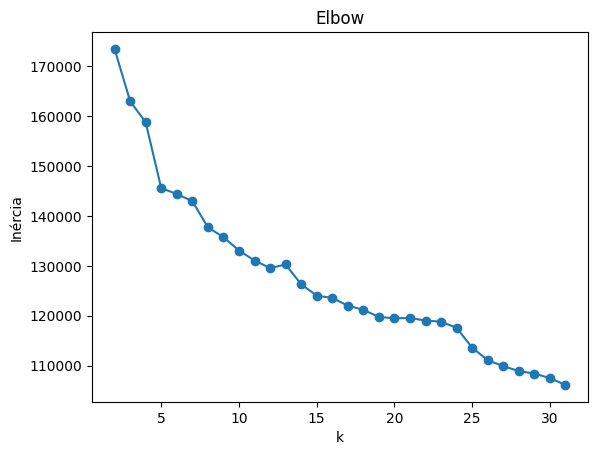

In [127]:
# Calcular inércia para diferentes k (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 32)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inércia')
plt.title('Elbow')
plt.show()

### Pergunta
8. Qual seria o K ideal pelo gráfico?

### Visualização de Clusters

In [128]:
# Ver top termos por cluster
import numpy as np

terms = vectorizer.get_feature_names_out()

for i in range(k):
    centroid = kmeans.cluster_centers_[i]
    top_idx = np.argsort(centroid)[-10:]
    print(f"\nCluster {i}:")
    print(", ".join(terms[top_idx]))


Cluster 0:
arquitetura, agronegócio, artesanato, administração administração, arte entretenimento, artes, beleza perda, administração autoajuda, autoajuda, administração

Cluster 1:
alternativa, beleza perda, autoajuda, beleza saúde, autoajuda espiritualidade, arte entretenimento, alimentação, administração financeira, arte, administração

Cluster 2:
beleza, beleza saúde, beleza perda, agronegócio, artesanato, artes, administração negócios, administração autoajuda, arquitetura, administração

Cluster 3:
arte entretenimento, beleza estética, autoajuda espiritualidade, arte, arquitetura, beleza, artes, alternativa, administração, administração administração

Cluster 4:
beleza perda, alternativa, beleza estética, beleza nutrição, beleza, beleza saúde, administração administração, administração, administração financeira, administração autoajuda

Cluster 5:
autoajuda espiritualidade, administração administração, autoajuda, beleza saúde, alternativa, administração negócios, arte, administra

In [129]:
# Ver exemplos de separação
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

display(
    df_final.groupby("cluster")["texto_final"]
    .apply(lambda x: x.sample(min(len(x), 4), random_state=42))
)

cluster     
0        127                                                                                                                             vendas
         310                                                                                                 pedagogia reforço escolar educação
         656                                                                                                                             vendas
         699                                                                                                                             vendas
1        657                                                                                                              saúde, dieta e beleza
         384                                                                                                        saúde saúde, dieta e beleza
         566                                                                                                              saúde, dieta e beleza
         397                                                                                                              saúde, dieta e beleza
2        668                                                                                                                              saúde
         178                                                                                                                              saúde
         521                                                                                                                     saúde nutrição
         190                                                                                                                              saúde
3        250                                                                                              tecnologia finanças marketing digital
         606                                                         arte e entretenimento marketing administração e negócios marketing digital
         247                                                                                              design e fotografia marketing digital
         494                                  marketing administração e gestão propaganda e marketing marketing digital consultoria empresarial
4        7                                                                                                          autoajuda e desenv. pessoal
         717                                                                                                        autoajuda e desenv. pessoal
         674                                                                                                        autoajuda e desenv. pessoal
         21                                                                                                         autoajuda e desenv. pessoal
5        20                                                                                                  educação física e esporte coaching
         693                                                                    educação física e esporte empreendedorismo educação e carreiras
         675                                                                                                          educação física e esporte
         50                                                                                                           educação física e esporte
6        39                                                                                                                   beleza e estética
         172                                                                                                                  beleza e estética
         334                                                                                                                  beleza e estética
         52                                                                                        

### Pergunta
9. Os dados estão sendo bem separados?
10. A sua conclusão como analista condiz com o Silhouete Score encontrado?

## Salvar o Dataset

In [130]:
display(df_final[["ClienteCod","categorias_limpas"]].sample(10))

,ClienteCod,categorias_limpas
677,57148779,[educação]
447,17752185,"[ensino religioso, evangélico, espiritualidade]"
541,740640821,"[cursos preparatórios, viagens]"
265,86048604,"[enfermagem, farmácia, saúde, odontologia, medicina]"
204,19018303,"[católico, evangélico, espiritualidade]"
731,1076114936,[educação]
559,88367385,"[arte e entretenimento, educação física e esporte, desenvolvimento pessoal, artes]"
720,94256102,[autoajuda e desenv. pessoal]
436,94124001,[cursos preparatórios]
500,15124225,[vendas]


In [131]:
from google.colab import files
df_final.to_parquet("/content/df_final.parquet")